# Task 4: Advanced Model — BERT Sentiment Classifier
**Smart Review Analyzer**

- Model: `distilbert-base-uncased` (أخف وأسرع من BERT الكامل وقريب في الدقة)
- Dataset: Amazon Reviews
- Input: `text_splits.csv` من outputs الـ Feature Extraction


## 0. Install & Imports

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# ── Device ───────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('All imports successful ✓')
print("done")

Using device: cuda
All imports successful ✓
done


## 1. Load Data
بنحمّل `text_splits.csv` اللي صاحبك حفظه من الـ Feature Extraction

In [19]:
DATA_PATH = './text_splits.csv'

df = pd.read_csv(DATA_PATH)
print(f'Total rows : {len(df):,}')
print(f'Columns    : {df.columns.tolist()}')
print(f'\nSplit distribution:')
print(df['split'].value_counts())
print(f'\nSentiment distribution:')
print(df['label'].value_counts())
df.head(3)

Total rows : 20,170
Columns    : ['split', 'text', 'label']

Split distribution:
split
train    16136
test      4034
Name: count, dtype: int64

Sentiment distribution:
label
0    14350
1     5820
Name: count, dtype: int64


,split,text,label
0,train,amazon amazing amazon amazing everything great...,1
1,train,never wish could give amazon poor servicei pla...,0
2,train,couldnt log account couldnt log account called...,0


In [20]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

X_train, y_train = train_df['text'].tolist(), train_df['label'].tolist()
X_test,  y_test  = test_df['text'].tolist(),  test_df['label'].tolist()

print(f'Train : {len(X_train):,} reviews')
print(f'Test  : {len(X_test):,}  reviews')

# class weight to solve imbalance data
classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
print(f'\nClass weights: Negative={weights[0]:.3f} | Positive={weights[1]:.3f}')

Train : 16,136 reviews
Test  : 4,034  reviews

Class weights: Negative=0.703 | Positive=1.733


## 2. Tokenization
BERT محتاج tokenizer خاص بيه مش بس split على spaces

In [ ]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME} ✓')

# an example on tokenization
sample = X_train[0]
encoded = tokenizer(sample, max_length=MAX_LEN, truncation=True, padding='max_length')
print(f'\nSample text    : {sample[:80]}...')
print(f'Input IDs len  : {len(encoded["input_ids"])}')
print(f'Attention mask : {encoded["attention_mask"][:10]}...')

Tokenizer loaded: distilbert-base-uncased ✓

Sample text    : amazon amazing amazon amazing everything great prices though canadian version li...
Input IDs len  : 128
Attention mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...


## 3. PyTorch Dataset & DataLoader

In [22]:
class ReviewDataset(Dataset):
    """
    Custom PyTorch Dataset للـ Amazon Reviews.
    بيحوّل كل review لـ tensors يقدر BERT ياخدها.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long)
        }


train_dataset = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader):,}')
print(f'Test  batches : {len(test_loader):,}')
print(f'Batch size    : {BATCH_SIZE}')

Train batches : 1,009
Test  batches : 253
Batch size    : 16


## 4. Build Model

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels = 2
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model loaded on: {DEVICE} ✓')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,955,010
Trainable parameters: 66,955,010
Model loaded on: cuda ✓


## 5. Training Setup

In [ ]:
# ── Hyperparameters
EPOCHS    = 5       
LR        = 2e-5  


optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = total_steps // 10   

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f'Epochs         : {EPOCHS}')
print(f'Learning rate  : {LR}')
print(f'Total steps    : {total_steps:,}')
print(f'Warmup steps   : {warmup_steps:,}')
print('Training setup complete ✓')

Epochs         : 5
Learning rate  : 2e-05
Total steps    : 5,045
Warmup steps   : 504
Training setup complete ✓


## 6. Training Loop

In [25]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """
    تدريب الموديل على epoch واحدة.
    بترجع average loss و accuracy للـ epoch.
    """
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        loss = loss_fn(logits, labels)
        loss.backward()

        # Gradient clipping عشان نمنع exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        # طباعة كل 100 batch
        if (batch_idx + 1) % 100 == 0:
            print(f'  Batch {batch_idx+1}/{len(loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, loss_fn, device):
    """
    تقييم الموديل على test set.
    بترجع loss, accuracy, predictions, true labels.
    """
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            loss        = loss_fn(logits, labels)
            total_loss += loss.item()

            preds    = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)


print('Training functions defined ✓')

Training functions defined ✓


In [ ]:
# ── Training Loop
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0

print('=' * 60)
print('Starting BERT Fine-tuning...')
print(f'Device: {DEVICE} | Epochs: {EPOCHS} | Batch: {BATCH_SIZE}')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    print(f'\nEpoch {epoch}/{EPOCHS}')
    print('-' * 40)

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    test_loss, test_acc, preds, labels = evaluate(
        model, test_loader, loss_fn, DEVICE
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}')

    
    if test_acc > best_acc:
        best_acc = test_acc
        os.makedirs('./outputs/models', exist_ok=True)
        torch.save(model.state_dict(), './outputs/models/bert_best.pt')
        print(f'  ✓ Best model saved! (acc={best_acc:.4f})')

print('\n' + '=' * 60)
print(f'Training Complete! Best Test Accuracy: {best_acc:.4f}')
print('=' * 60)

Starting BERT Fine-tuning...
Device: cuda | Epochs: 5 | Batch: 16

Epoch 1/5
----------------------------------------
  Batch 100/1009 | Loss: 0.5999
  Batch 200/1009 | Loss: 0.1224
  Batch 300/1009 | Loss: 0.4584
  Batch 400/1009 | Loss: 0.2155
  Batch 500/1009 | Loss: 0.5166
  Batch 600/1009 | Loss: 0.0106
  Batch 700/1009 | Loss: 0.0289
  Batch 800/1009 | Loss: 0.4140
  Batch 900/1009 | Loss: 0.5733
  Batch 1000/1009 | Loss: 0.0099
  Train Loss: 0.2776 | Train Acc: 0.8992
  Test  Loss: 0.1801 | Test  Acc: 0.9390
  ✓ Best model saved! (acc=0.9390)

Epoch 2/5
----------------------------------------
  Batch 100/1009 | Loss: 0.0063
  Batch 200/1009 | Loss: 0.0043
  Batch 300/1009 | Loss: 0.4220
  Batch 400/1009 | Loss: 0.0145
  Batch 500/1009 | Loss: 0.0159
  Batch 600/1009 | Loss: 0.0046
  Batch 700/1009 | Loss: 0.0035
  Batch 800/1009 | Loss: 0.0108
  Batch 900/1009 | Loss: 0.0043
  Batch 1000/1009 | Loss: 0.2586
  Train Loss: 0.1254 | Train Acc: 0.9714
  Test  Loss: 0.1655 | Test  A

## 7. Evaluation & Metrics

In [ ]:
model.load_state_dict(torch.load('./outputs/models/bert_best.pt', map_location=DEVICE))

_, final_acc, final_preds, final_labels = evaluate(
    model, test_loader, loss_fn, DEVICE
)

print('=' * 60)
print('BERT — Final Evaluation on Test Set')
print('=' * 60)
print(f'Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)')
print()
print(classification_report(
    final_labels, final_preds,
    target_names=['Negative', 'Positive']
))

BERT — Final Evaluation on Test Set
Accuracy: 0.9593 (95.93%)

              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97      2870
    Positive       0.93      0.93      0.93      1164

    accuracy                           0.96      4034
   macro avg       0.95      0.95      0.95      4034
weighted avg       0.96      0.96      0.96      4034



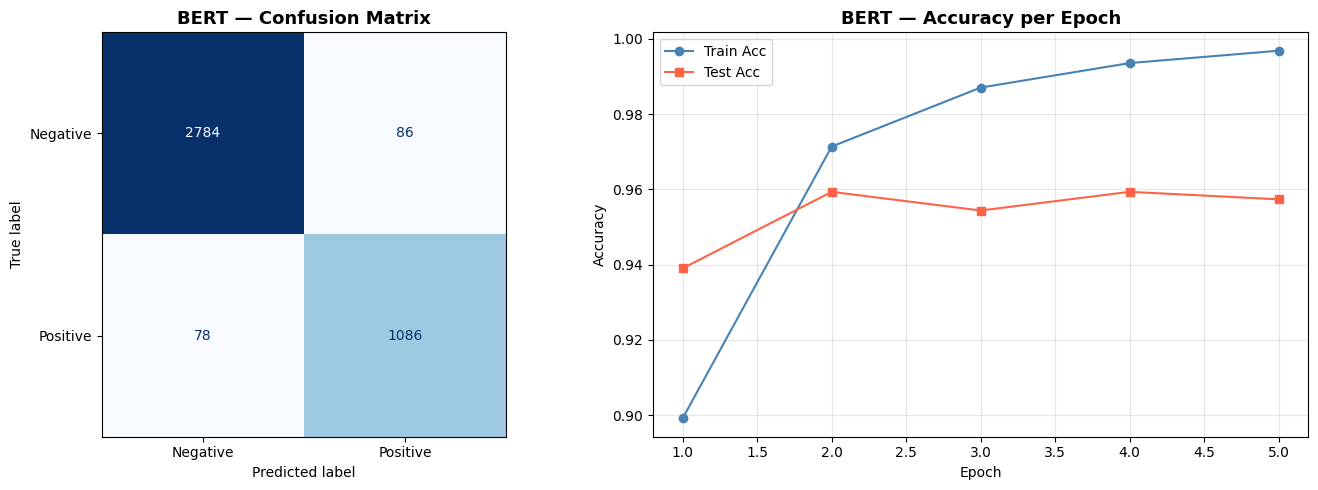

Figure saved ✓


In [28]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(final_labels, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('BERT — Confusion Matrix', fontsize=13, fontweight='bold')

# Training History
epochs_range = range(1, EPOCHS + 1)
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Acc', color='steelblue')
axes[1].plot(epochs_range, history['test_acc'],  's-', label='Test Acc',  color='tomato')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERT — Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../src/figures', exist_ok=True)
plt.savefig('../src/figures/bert_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

## 8. Insights Extraction
استخراج insights من نتائج الموديل (المطلوب في المشروع)

In [ ]:
results_df = test_df.copy()
results_df['predicted']  = final_preds
results_df['correct']    = (results_df['label'] == results_df['predicted'])
results_df['sentiment_label']   = results_df['label'].map({0: 'Negative', 1: 'Positive'})
results_df['predicted_label']   = results_df['predicted'].map({0: 'Negative', 1: 'Positive'})

print('Results DataFrame created ✓')
results_df.head()

Results DataFrame created ✓


,split,text,label,predicted,correct,sentiment_label,predicted_label
0,test,yet another delivery delayed yet another deliv...,0,0,True,Negative,Negative
1,test,amazon crooks hiding behind garbage sellers am...,0,0,True,Negative,Negative
2,test,happened amazon late happened amazon latei fou...,0,0,True,Negative,Negative
3,test,amazon customer service sucks double charged t...,0,0,True,Negative,Negative
4,test,bad experience amazon uk… bad experience amazo...,0,0,True,Negative,Negative


In [ ]:
# ── Statistics 
total     = len(results_df)
pos_count = (results_df['predicted'] == 1).sum()
neg_count = (results_df['predicted'] == 0).sum()

print('=' * 50)
print('BERT Prediction Statistics')
print('=' * 50)
print(f'Total reviews   : {total:,}')
print(f'Positive (pred) : {pos_count:,} ({pos_count/total*100:.1f}%)')
print(f'Negative (pred) : {neg_count:,} ({neg_count/total*100:.1f}%)')


errors = results_df[~results_df['correct']]
fp = len(errors[errors['label'] == 0])  
fn = len(errors[errors['label'] == 1])  
print(f'\nFalse Positives : {fp} (Negative predicted as Positive)')
print(f'False Negatives : {fn} (Positive predicted as Negative)')

BERT Prediction Statistics
Total reviews   : 4,034
Positive (pred) : 1,172 (29.1%)
Negative (pred) : 2,862 (70.9%)

False Positives : 86 (Negative predicted as Positive)
False Negatives : 78 (Positive predicted as Negative)


In [ ]:
print('=' * 60)
print('Sample Predictions with Reasoning')
print('=' * 60)


positive_keywords = ['great', 'good', 'love', 'excellent', 'best', 'amazing', 'fast', 'easy']
negative_keywords = ['slow', 'bad', 'terrible', 'never', 'refund', 'cancel', 'delay', 'broken',
                     'worst', 'awful', 'disappointed', 'damaged', 'missing', 'lost']

def extract_reason(text, sentiment):
    """استخراج السبب من النص بناءً على الـ keywords"""
    words = text.lower().split()
    if sentiment == 0:  # Negative
        found = [w for w in words if w in negative_keywords]
        return f"Reason: '{', '.join(found[:3])}' mentioned" if found else "Reason: negative tone detected"
    else:  # Positive
        found = [w for w in words if w in positive_keywords]
        return f"Reason: '{', '.join(found[:3])}' mentioned" if found else "Reason: positive tone detected"

sample_results = results_df.sample(5, random_state=42)
for _, row in sample_results.iterrows():
    sentiment = row['predicted_label']
    reason    = extract_reason(row['text'], row['predicted'])
    correct   = '✓' if row['correct'] else '✗'
    print(f"\n{correct} Review : {str(row['text'])[:80]}...")
    print(f"   → {sentiment} | {reason}")

Sample Predictions with Reasoning

✓ Review : carol moss london highly recommended much books started ever looking worth check...
   → Positive | Reason: 'excellent' mentioned

✓ Review : online shopping online shopping far best experience ive online ordering using eb...
   → Positive | Reason: 'best, great' mentioned

✓ Review : good years good years past year horrible multiple lost packages consistently lat...
   → Negative | Reason: 'lost, refund' mentioned

✓ Review : useful website seem have… useful website seem everything need quick deliveries i...
   → Positive | Reason: positive tone detected

✓ Review : company product effective… company product effective workes nice...
   → Positive | Reason: positive tone detected


In [32]:
# ── Common Patterns ───────────────────────────────────────────────────────
from collections import Counter

def get_top_keywords(texts, keywords_list, top_n=10):
    """أكتر الـ keywords ظهوراً في النصوص"""
    counter = Counter()
    for text in texts:
        words = text.lower().split()
        for word in words:
            if word in keywords_list:
                counter[word] += 1
    return counter.most_common(top_n)

neg_texts = results_df[results_df['predicted'] == 0]['text']
pos_texts = results_df[results_df['predicted'] == 1]['text']

top_neg = get_top_keywords(neg_texts, negative_keywords)
top_pos = get_top_keywords(pos_texts, positive_keywords)

print('Common Patterns — Negative Reviews:')
for word, count in top_neg:
    print(f'  {word:<15} → {count:,} mentions')

print('\nCommon Patterns — Positive Reviews:')
for word, count in top_pos:
    print(f'  {word:<15} → {count:,} mentions')

Common Patterns — Negative Reviews:
  refund          → 887 mentions
  never           → 808 mentions
  bad             → 353 mentions
  worst           → 349 mentions
  lost            → 229 mentions
  cancel          → 215 mentions
  terrible        → 195 mentions
  damaged         → 123 mentions
  disappointed    → 119 mentions
  awful           → 109 mentions

Common Patterns — Positive Reviews:
  great           → 388 mentions
  good            → 328 mentions
  love            → 236 mentions
  best            → 234 mentions
  fast            → 170 mentions
  excellent       → 156 mentions
  easy            → 130 mentions
  amazing         → 104 mentions


## 9. Summary

In [34]:
print('=' * 60)
print('BERT Model — Final Summary')
print('=' * 60)
print(f'Model          : DistilBERT (distilbert-base-uncased)')
print(f'Max Seq Length : {MAX_LEN}')
print(f'Epochs         : {EPOCHS}')
print(f'Batch Size     : {BATCH_SIZE}')
print(f'Learning Rate  : {LR}')
print(f'Device         : {DEVICE}')
print(f'Test Accuracy  : {final_acc:.4f} ({final_acc*100:.2f}%)')
print('=' * 60)
print('Outputs saved to ../outputs/')
print('  models/bert_best.pt')
print('  results/model_comparison.csv')
print('  figures/bert_evaluation.png (via src/figures)')

BERT Model — Final Summary
Model          : DistilBERT (distilbert-base-uncased)
Max Seq Length : 128
Epochs         : 5
Batch Size     : 16
Learning Rate  : 2e-05
Device         : cuda
Test Accuracy  : 0.9593 (95.93%)
Outputs saved to ../outputs/
  models/bert_best.pt
  results/model_comparison.csv
  figures/bert_evaluation.png (via src/figures)
